In [1]:
!pip install -q "protobuf==3.20.3" keras-flops

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 5.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.26.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
grain 0.2.15 requires protobuf>=5.28.3, but you have protobuf 3.20.3 which is incompatible.
onnx 1.20.0 requires protobuf>=4.25.1, but you have protobuf 3.20.3 which is incompatible.
ray 2.52.1 requires click!=8.3.*,>=7.0, but you have click 8.3.1 which is incompatible.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 3.20.3 which is incompatible.
tensorflow-metadata 1.17.2 requires protobuf>=4.25.2; python_version >= "3.11", but you have protobuf 3.20.3 which is incompatible.
ydf 0.13.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 3.20.3 which is incompatible.
bigframes 2.26.0 requires rich<14,>=12.4.

In [9]:
import os
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
from tensorflow.keras import layers, models, optimizers, losses
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.python.profiler.model_analyzer import profile
from tensorflow.python.profiler.option_builder import ProfileOptionBuilder

# Seed for reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print(f"TensorFlow Version: {tf.__version__}")
gpu_devices = tf.config.experimental.list_physical_devices('GPU')
if gpu_devices:
    print(f"GPU Detected: {gpu_devices}")
else:
    print("No GPU detected. Running on CPU.")

TensorFlow Version: 2.19.0
GPU Detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [10]:
# --- DATASET CONFIGURATION (Paper Section IV.B: Pre-split Data) ---

BASE_DIR = "/kaggle/input/kdlight-dataset/KDLightDataSet"
TRAIN_DIR = os.path.join(BASE_DIR, "Train")
VAL_DIR = os.path.join(BASE_DIR, "Val")
TEST_DIR = os.path.join(BASE_DIR, "Test")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Verify directories exist
if not os.path.exists(TRAIN_DIR):
    raise FileNotFoundError(f"Train directory not found at {TRAIN_DIR}")

In [11]:
# %% [code] {"jupyter":{"outputs_hidden":false}}
# --- DATA GENERATORS ---

# Scaling only
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

print("Loading Training Data:")
# Let Train generator auto-detect the available classes
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

# EXTRACT CLASSES FROM TRAIN TO ENFORCE CONSISTENCY
# This ensures Val and Test only use the 14 classes found in Train
# and ignore 'Viral Pneumonia' or any other extra folders.
DETECTED_CLASSES = list(train_gen.class_indices.keys())
print(f"Classes to enforce on Val/Test: {DETECTED_CLASSES}")

print("Loading Validation Data:")
val_gen = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=DETECTED_CLASSES, # <--- Filter based on Train classes
    shuffle=False,
    seed=SEED
)

print("Loading Test Data:")
test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=DETECTED_CLASSES, # <--- Filter based on Train classes
    shuffle=False,
    seed=SEED
)

NUM_CLASSES = len(DETECTED_CLASSES)
CLASS_LABELS = DETECTED_CLASSES
print(f"\nFinal Class Count: {NUM_CLASSES}")
print(f"Classes: {CLASS_LABELS}")

Loading Training Data:
Found 7756 images belonging to 14 classes.
Classes to enforce on Val/Test: ['BA-impetigo', 'COVID', 'Colorectal cancer', 'Esophagitis', 'High_squamous', 'Low_squamous', 'Lung_Opacity', 'Negative', 'Pylorus', 'SCC', 'VI-chickenpox', 'glioma', 'meningioma', 'pituitary']
Loading Validation Data:
Found 861 images belonging to 14 classes.
Loading Test Data:
Found 2032 images belonging to 14 classes.

Final Class Count: 14
Classes: ['BA-impetigo', 'COVID', 'Colorectal cancer', 'Esophagitis', 'High_squamous', 'Low_squamous', 'Lung_Opacity', 'Negative', 'Pylorus', 'SCC', 'VI-chickenpox', 'glioma', 'meningioma', 'pituitary']


In [12]:
# --- TEACHER MODEL: MobileNetV1 (Paper Section III.A) ---

def build_teacher_model(num_classes):
    # MobileNetV1 base [cite: 25]
    base = MobileNet(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dense(1024, activation='relu')(x) 
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs=base.input, outputs=outputs, name="Teacher_MobileNet")

teacher_model = build_teacher_model(NUM_CLASSES)
teacher_model.compile(optimizer=optimizers.Adam(learning_rate=1e-3), 
                      loss='categorical_crossentropy', 
                      metrics=['accuracy'])

I0000 00:00:1769279826.988600      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [13]:
# --- STUDENT MODEL: KDLight (Paper Table I) ---

def build_kdlight_student(num_classes):
    inputs = layers.Input(shape=(224, 224, 3))
    
    # Block 1 (Paper Table I: 224->222->111)
    x = layers.Conv2D(32, (3, 3), padding='valid', activation='relu', name="Conv2d_1st")(inputs)
    x = layers.MaxPooling2D((2, 2), name="Max_Pooling_1")(x)
    
    # Block 2 (Paper Table I: 111->109->54)
    x = layers.Conv2D(32, (3, 3), padding='valid', activation='relu', name="Conv2d_2nd")(x)
    x = layers.MaxPooling2D((2, 2), name="Max_Pooling_2")(x)
    x = layers.Dropout(0.25)(x)
    
    # Block 3 (Paper Table I: 54->52->50->25)
    x = layers.Conv2D(64, (3, 3), padding='valid', activation='relu', name="Conv2d_3rd")(x)
    x = layers.Conv2D(64, (3, 3), padding='valid', activation='relu', name="Conv2d_4th")(x)
    x = layers.MaxPooling2D((2, 2), name="Max_Pooling_3")(x)
    x = layers.Dropout(0.25)(x)
    
    # Block 4 (Paper Table I: 25->23->21->10)
    x = layers.Conv2D(128, (3, 3), padding='valid', activation='relu', name="Conv2d_5th")(x)
    x = layers.Conv2D(128, (3, 3), padding='valid', activation='relu', name="Conv2d_6th")(x)
    x = layers.MaxPooling2D((2, 2), name="Max_Pooling_4")(x)
    x = layers.Dropout(0.25)(x)
    
    # Block 5 (Resolution 10x10 preserved)
    # Using 64 filters to match Flatten output of 6400 (10x10x64) [cite: 133, 178]
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu', name="Conv2d_7th")(x)
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu', name="Conv2d_8th")(x)
    
    # Classification Head
    x = layers.Flatten(name="Flatten")(x) # Output 6400
    x = layers.Dense(128, activation='relu', name="Dense_128")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.25)(x)
    
    x = layers.Dense(64, activation='relu', name="Dense_64")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    
    outputs = layers.Dense(num_classes, activation='softmax', name="Output")(x)
    
    return models.Model(inputs=inputs, outputs=outputs, name="KDLight_Student")

student_model_kd = build_kdlight_student(NUM_CLASSES)

In [14]:
# --- KNOWLEDGE DISTILLATION FRAMEWORK (Paper Section III.A: Eq 1-3) ---

class KDLight_Distiller(models.Model):
    def __init__(self, student, teacher):
        super(KDLight_Distiller, self).__init__()
        self.teacher = teacher
        self.student = student

    def compile(self, optimizer, metrics, student_loss_fn, distillation_loss_fn, alpha=0.5, beta=0.5, temperature=5):
        super(KDLight_Distiller, self).compile(optimizer=optimizer, metrics=metrics)
        self.student_loss_fn = student_loss_fn
        self.distillation_loss_fn = distillation_loss_fn
        self.alpha = alpha
        self.beta = beta
        self.temperature = temperature

    def train_step(self, data):
        x, y = data
        
        # Teacher Forward Pass (Training=False)
        teacher_predictions = self.teacher(x, training=False)
        
        with tf.GradientTape() as tape:
            # Student Forward Pass
            student_predictions = self.student(x, training=True)
            
            # 1. Hard Loss (Cross Entropy) [cite: 108]
            student_loss = self.student_loss_fn(y, student_predictions)
            
            # 2. Soft Loss (Distillation) with Temperature [cite: 109, 118, 122]
            teacher_soft = tf.nn.softmax(teacher_predictions / self.temperature, axis=1)
            student_soft = tf.nn.softmax(student_predictions / self.temperature, axis=1)
            
            # Scaled distillation loss
            distillation_loss = self.distillation_loss_fn(teacher_soft, student_soft) * (self.temperature ** 2)
            
            # Total Loss [cite: 108]
            loss = self.alpha * student_loss + self.beta * distillation_loss

        # Backpropagation
        gradients = tape.gradient(loss, self.student.trainable_variables)
        self.optimizer.apply_gradients(zip(gradients, self.student.trainable_variables))
        
        self.compiled_metrics.update_state(y, student_predictions)
        results = {m.name: m.result() for m in self.metrics}
        results.update({"student_loss": student_loss, "distill_loss": distillation_loss, "total_loss": loss})
        return results

    def test_step(self, data):
        x, y = data
        y_pred = self.student(x, training=False)
        student_loss = self.student_loss_fn(y, y_pred)
        self.compiled_metrics.update_state(y, y_pred)
        results = {m.name: m.result() for m in self.metrics}
        results.update({"student_loss": student_loss})
        return results

In [17]:
# --- EXPERIMENT 1: TRAIN TEACHER (MobileNet) ---

print("=== Training Teacher (MobileNet) ===")
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
    ModelCheckpoint('teacher_mobilenet.keras', save_best_only=True)
]

start_time = time.time()
teacher_history = teacher_model.fit(
    train_gen,
    epochs=20, # [cite: 142]
    validation_data=val_gen,
    callbacks=callbacks
)
teacher_train_time = time.time() - start_time
print(f"Teacher Training Time: {teacher_train_time:.2f}s")

=== Training Teacher (MobileNet) ===


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


I0000 00:00:1769279865.917968     194 service.cc:152] XLA service 0x7b90d0002dd0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1769279865.918019     194 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1769279868.085861     194 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-01-24 18:37:55.518899: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-24 18:37:55.718641: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1769279881.759532     194 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the proc

201/243 ━━━━━━━━━━━━━━━━━━━━ 14s 357ms/step - accuracy: 0.7796 - loss: 0.7258

2026-01-24 18:39:22.343541: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-24 18:39:22.541829: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


243/243 ━━━━━━━━━━━━━━━━━━━━ 157s 496ms/step - accuracy: 0.7952 - loss: 0.6693 - val_accuracy: 0.6551 - val_loss: 1.3985
Epoch 2/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 63s 258ms/step - accuracy: 0.9222 - loss: 0.2199 - val_accuracy: 0.8955 - val_loss: 0.2742
Epoch 3/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 60s 247ms/step - accuracy: 0.9588 - loss: 0.1295 - val_accuracy: 0.9094 - val_loss: 0.3957
Epoch 4/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 61s 250ms/step - accuracy: 0.9521 - loss: 0.1385 - val_accuracy: 0.8827 - val_loss: 0.5386
Epoch 5/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 62s 255ms/step - accuracy: 0.9745 - loss: 0.0675 - val_accuracy: 0.9408 - val_loss: 0.1541
Epoch 6/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 60s 248ms/step - accuracy: 0.9793 - loss: 0.0652 - val_accuracy: 0.9350 - val_loss: 0.1994
Epoch 7/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 61s 253ms/step - accuracy: 0.9839 - loss: 0.0544 - val_accuracy: 0.8084 - val_loss: 0.6506
Epoch 8/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 61s 251ms/step - accuracy: 0.9682 - loss: 0.0944 - va

In [18]:
# --- EXPERIMENT 2: TRAIN STUDENT (KDLight) via DISTILLATION ---

print("=== Training KDLight Student via Distillation ===")

# Optimizer setup with clipnorm for stability
opt = optimizers.Adam(learning_rate=1e-3, clipnorm=1.0) # [cite: 138]

distiller = KDLight_Distiller(student=student_model_kd, teacher=teacher_model)
distiller.compile(
    optimizer=opt,
    metrics=['accuracy'],
    student_loss_fn=losses.CategoricalCrossentropy(from_logits=False),
    distillation_loss_fn=losses.KLDivergence(),
    alpha=0.5,
    beta=0.5,
    temperature=5 
)

kd_history = distiller.fit(
    train_gen,
    epochs=20, # [cite: 142]
    validation_data=val_gen
)
student_model_kd.save('kdlight_student.keras')

=== Training KDLight Student via Distillation ===
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:646: UserWarning: `model.compiled_metrics()` is deprecated. Instead, use e.g.:
```
for metric in self.metrics:
    metric.update_state(y, y_pred)
```

  return self._compiled_metrics_update_state(


243/243 ━━━━━━━━━━━━━━━━━━━━ 93s 306ms/step - accuracy: 0.3718 - distill_loss: 0.0262 - loss: 0.0714 - student_loss: 1.6008 - total_loss: 0.8135 - val_loss: 0.0714 - val_student_loss: 1.3956
Epoch 2/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 62s 257ms/step - accuracy: 0.5842 - distill_loss: 0.0210 - loss: 0.0714 - student_loss: 1.1274 - total_loss: 0.5742 - val_loss: 0.0714 - val_student_loss: 2.9603
Epoch 3/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 62s 255ms/step - accuracy: 0.6254 - distill_loss: 0.0186 - loss: 0.0714 - student_loss: 0.9603 - total_loss: 0.4894 - val_loss: 0.0714 - val_student_loss: 0.4231
Epoch 4/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 63s 260ms/step - accuracy: 0.6709 - distill_loss: 0.0164 - loss: 0.0714 - student_loss: 0.8255 - total_loss: 0.4210 - val_loss: 0.0714 - val_student_loss: 1.2972
Epoch 5/20
243/243 ━━━━━━━━━━━━━━━━━━━━ 62s 256ms/step - accuracy: 0.7105 - distill_loss: 0.0149 - loss: 0.0714 - student_loss: 0.7359 - total_loss: 0.3754 - val_loss: 0.0714 - val_student_loss: 0.6168
E

In [19]:
# --- EVALUATION METRICS & COMPLEXITY ANALYSIS (Table V) ---

def get_flops(model):
    forward_pass = tf.function(model.call, input_signature=[tf.TensorSpec(shape=(1,) + model.input_shape[1:], dtype=tf.float32)])
    graph_info = profile(forward_pass.get_concrete_function().graph, options=ProfileOptionBuilder.float_operation())
    return graph_info.total_float_ops

def get_model_size(file_path):
    if os.path.exists(file_path):
        return os.path.getsize(file_path) / (1024 * 1024)
    return 0

def measure_inference_time(model, sample_batch):
    start = time.time()
    model.predict(sample_batch, verbose=0)
    end = time.time()
    return (end - start)

# Generate Metrics
sample_batch, _ = next(iter(test_gen))
teacher_flops = get_flops(teacher_model)
student_flops = get_flops(student_model_kd)

teacher_size = get_model_size('teacher_mobilenet.keras')
student_size = get_model_size('kdlight_student.keras')

teacher_inf_time = measure_inference_time(teacher_model, sample_batch)
student_inf_time = measure_inference_time(student_model_kd, sample_batch)

complexity_df = pd.DataFrame({
    'Model': ['Teacher (MobileNet)', 'Student (KDLight)'],
    'Memory (MB)': [f"{teacher_size:.2f}", f"{student_size:.2f}"], # [cite: 257]
    'FLOPs': [f"{teacher_flops:,}", f"{student_flops:,}"], # [cite: 257]
    'Test Time (sec)': [f"{teacher_inf_time:.4f}", f"{student_inf_time:.4f}"] # [cite: 257]
})
print("\n=== Table V: Complexity Analysis ===")
print(complexity_df)

Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.

=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
scope: The nodes in the model g

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


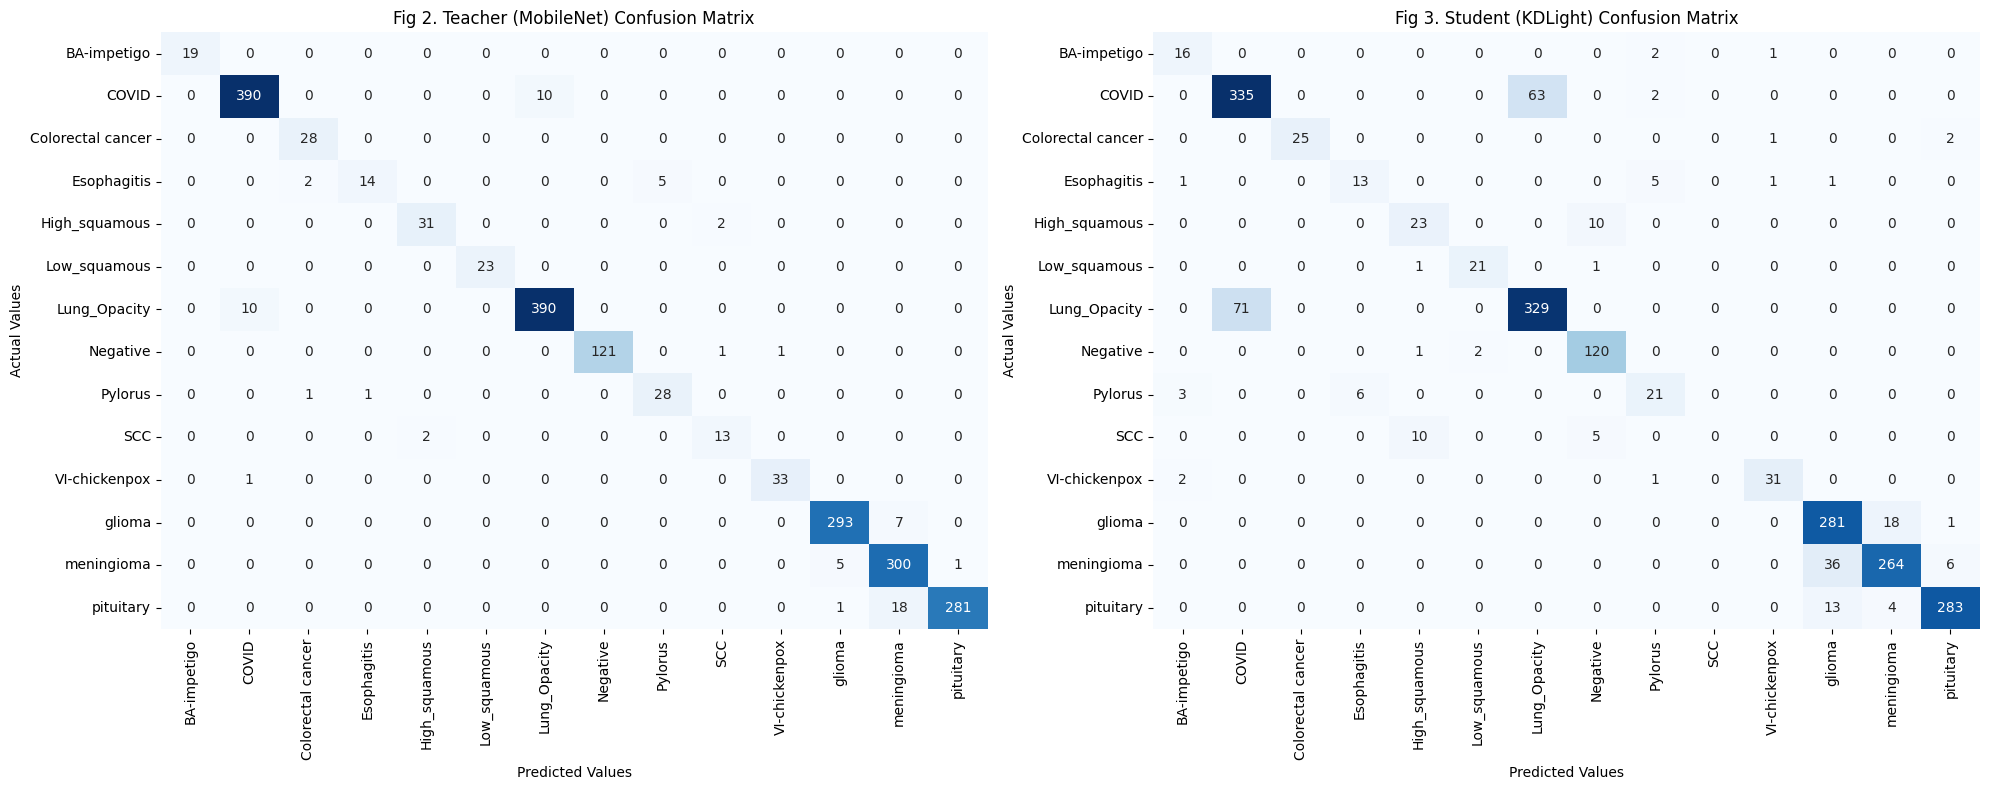

In [20]:
# --- PERFORMANCE VISUALIZATIONS ---

def plot_confusion_matrix(model, title, ax):
    test_gen.reset()
    y_pred_prob = model.predict(test_gen, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = test_gen.classes
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS, ax=ax, cbar=False)
    ax.set_title(title)
    ax.set_ylabel('Actual Values')
    ax.set_xlabel('Predicted Values')
    return y_true, y_pred_prob

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
y_true, y_pred_teacher = plot_confusion_matrix(teacher_model, "Fig 2. Teacher (MobileNet) Confusion Matrix", axes[0])
y_true, y_pred_student = plot_confusion_matrix(student_model_kd, "Fig 3. Student (KDLight) Confusion Matrix", axes[1])
plt.tight_layout()
plt.show()

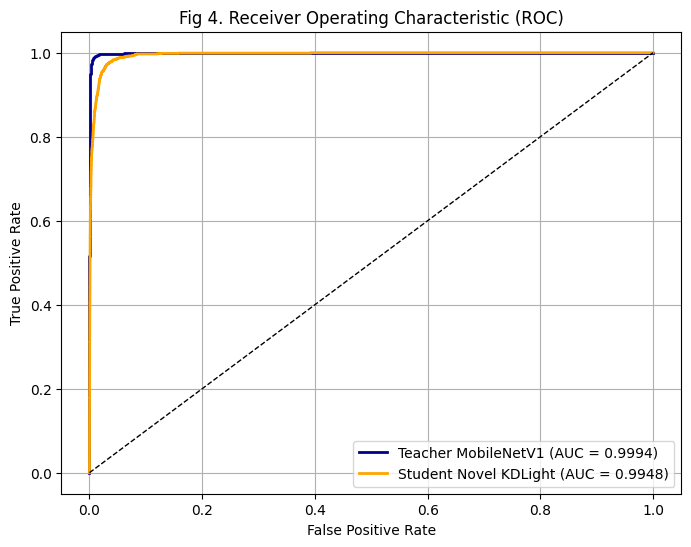

In [21]:
# --- ROC-AUC CURVE (Figure 4) ---

def plot_roc_auc(y_true, y_pred_teacher, y_pred_student, n_classes):
    y_true_bin = label_binarize(y_true, classes=range(n_classes))
    
    # Compute Micro-Average ROC
    fpr_t, tpr_t, _ = roc_curve(y_true_bin.ravel(), y_pred_teacher.ravel())
    auc_t = auc(fpr_t, tpr_t)
    
    fpr_s, tpr_s, _ = roc_curve(y_true_bin.ravel(), y_pred_student.ravel())
    auc_s = auc(fpr_s, tpr_s)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr_t, tpr_t, color='darkblue', linestyle='-', lw=2, label=f'Teacher MobileNetV1 (AUC = {auc_t:.4f})')
    plt.plot(fpr_s, tpr_s, color='orange', linestyle='-', lw=2, label=f'Student Novel KDLight (AUC = {auc_s:.4f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Fig 4. Receiver Operating Characteristic (ROC)')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

plot_roc_auc(y_true, y_pred_teacher, y_pred_student, NUM_CLASSES)

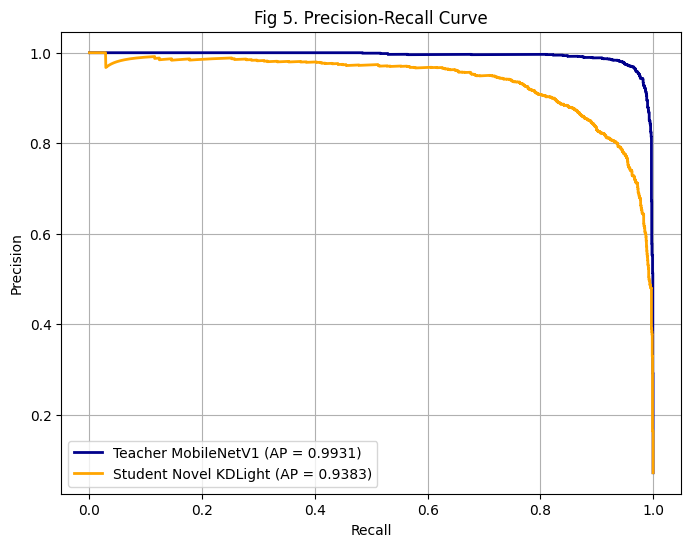

In [22]:
# --- PRECISION-RECALL CURVE (Figure 5) ---

def plot_pr_curve(y_true, y_pred_teacher, y_pred_student, n_classes):
    y_true_bin = label_binarize(y_true, classes=range(n_classes))
    
    # Micro-Average PR
    precision_t, recall_t, _ = precision_recall_curve(y_true_bin.ravel(), y_pred_teacher.ravel())
    ap_t = average_precision_score(y_true_bin, y_pred_teacher, average="micro")
    
    precision_s, recall_s, _ = precision_recall_curve(y_true_bin.ravel(), y_pred_student.ravel())
    ap_s = average_precision_score(y_true_bin, y_pred_student, average="micro")
    
    plt.figure(figsize=(8, 6))
    plt.plot(recall_t, precision_t, color='darkblue', lw=2, label=f'Teacher MobileNetV1 (AP = {ap_t:.4f})')
    plt.plot(recall_s, precision_s, color='orange', lw=2, label=f'Student Novel KDLight (AP = {ap_s:.4f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Fig 5. Precision-Recall Curve')
    plt.legend(loc="lower left")
    plt.grid(True)
    plt.show()

plot_pr_curve(y_true, y_pred_teacher, y_pred_student, NUM_CLASSES)

In [23]:
# --- CLASS-WISE PERFORMANCE (Table III) ---

def generate_performance_table(y_true, y_pred_prob, model_name):
    y_pred = np.argmax(y_pred_prob, axis=1)
    report = classification_report(y_true, y_pred, target_names=CLASS_LABELS, output_dict=True)
    
    data = []
    for cls in CLASS_LABELS:
        row = {
            'Model': model_name,
            'Class': cls,
            'Precision': f"{report[cls]['precision']:.2f}",
            'Recall': f"{report[cls]['recall']:.2f}",
            'F1-Score': f"{report[cls]['f1-score']:.2f}"
        }
        data.append(row)
    
    # Add Overall Accuracy row
    data.append({
        'Model': model_name, 
        'Class': 'OVERALL ACCURACY', 
        'Precision': '-', 
        'Recall': '-', 
        'F1-Score': f"{report['accuracy']:.2%}"
    })
    
    return pd.DataFrame(data)

df_teacher = generate_performance_table(y_true, y_pred_teacher, "Teacher (MobileNet)")
df_student = generate_performance_table(y_true, y_pred_student, "Student (KDLight)")

print("\n=== Table III: Class-Wise Performance Evaluation ===")
print(pd.concat([df_teacher, df_student], ignore_index=True))


=== Table III: Class-Wise Performance Evaluation ===
                  Model              Class Precision Recall F1-Score
0   Teacher (MobileNet)        BA-impetigo      1.00   1.00     1.00
1   Teacher (MobileNet)              COVID      0.97   0.97     0.97
2   Teacher (MobileNet)  Colorectal cancer      0.90   1.00     0.95
3   Teacher (MobileNet)        Esophagitis      0.93   0.67     0.78
4   Teacher (MobileNet)      High_squamous      0.94   0.94     0.94
5   Teacher (MobileNet)       Low_squamous      1.00   1.00     1.00
6   Teacher (MobileNet)       Lung_Opacity      0.97   0.97     0.97
7   Teacher (MobileNet)           Negative      1.00   0.98     0.99
8   Teacher (MobileNet)            Pylorus      0.85   0.93     0.89
9   Teacher (MobileNet)                SCC      0.81   0.87     0.84
10  Teacher (MobileNet)      VI-chickenpox      0.97   0.97     0.97
11  Teacher (MobileNet)             glioma      0.98   0.98     0.98
12  Teacher (MobileNet)         meningioma      0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
